In [ ]:
import pandas as pd

from sklearn.datasets import fetch_openml

# Load dataset
data = fetch_openml(name="credit-g", as_frame=True)

df = data.frame

df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name credit-g exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=31
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=44096

  warn(warning_msg)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [ ]:
df.shape


(1000, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

In [ ]:
df["class"].value_counts()

,count
class,
good,700
bad,300


In [ ]:
df["class"].value_counts(normalize=True)

,proportion
class,
good,0.7
bad,0.3


In [ ]:
df.isnull().sum()

,0
checking_status,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment,0
installment_commitment,0
personal_status,0
other_parties,0


In [ ]:
df["class"] = df["class"].map({
    "good": 0,
    "bad": 1
})

df["class"].value_counts()

,count
class,
0,700
1,300


In [ ]:
X = df.drop("class", axis=1)

y = df["class"]

categorical_cols = X.select_dtypes(
    include=["category", "object"]
).columns

len(categorical_cols)

13

In [ ]:
X.dtypes

,0
checking_status,category
duration,int64
credit_history,category
purpose,category
credit_amount,int64
savings_status,category
employment,category
installment_commitment,int64
personal_status,category
other_parties,category


In [ ]:
numeric_cols =  X.select_dtypes(
    include=["int64"]
).columns
len(numeric_cols)

7

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)
preprocessor

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
       'employment', 'personal_status', 'other_parties', 'property_magnitude',
       'other_payment_plans', 'housing', 'job', 'own_telephone',
       'foreign_worker'],
      dtype='object')),
                                ('num', 'passthrough',
                                 Index(['duration', 'credit_amount', 'installment_commitment',
       'residence_since', 'age', 'existing_credits', 'num_dependents'],
      dtype='object'))])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])
pipe

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
       'employment', 'personal_status', 'other_parties', 'property_magnitude',
       'other_payment_plans', 'housing', 'job', 'own_telephone',
       'foreign_worker'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['duration', 'credit_amount', 'installment_commitment',
       'residence_since', 'age', 'existing_credits', 'num_dependents'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.shape, X_test.shape

((800, 20), (200, 20))

In [ ]:
pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
       'employment', 'personal_status', 'other_parties', 'property_magnitude',
       'other_payment_plans', 'housing', 'job', 'own_telephone',
       'foreign_worker'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['duration', 'credit_amount', 'installment_commitment',
       'residence_since', 'age', 'existing_credits', 'num_dependents'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
preds = pipe.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       140
           1       0.64      0.53      0.58        60

    accuracy                           0.77       200
   macro avg       0.73      0.70      0.71       200
weighted avg       0.76      0.77      0.76       200



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

cm

array([[122,  18],
       [ 28,  32]])

In [ ]:
probs = pipe.predict_proba(X_test)[:,1]

In [ ]:
import numpy as np
new_preds = (probs > 0.3).astype(int)

In [ ]:
print(classification_report(y_test, new_preds))

              precision    recall  f1-score   support

           0       0.89      0.73      0.80       140
           1       0.56      0.80      0.66        60

    accuracy                           0.75       200
   macro avg       0.73      0.76      0.73       200
weighted avg       0.79      0.75      0.76       200



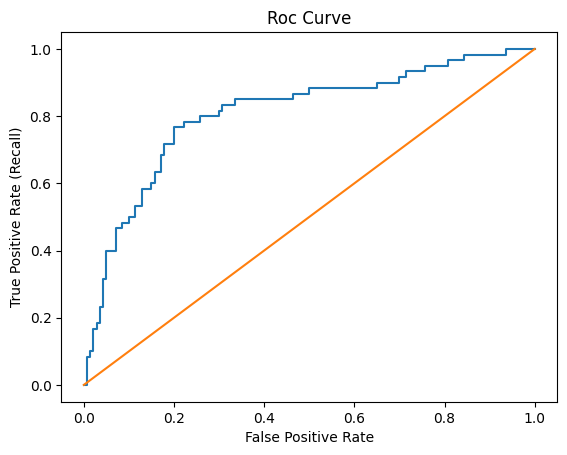

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.plot(figsize=(6, 4))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Roc Curve")

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, probs)

roc_auc

np.float64(0.8075)

In [ ]:
import numpy as np

# Find best threshold using Youden's J statistic
J = tpr - fpr

ix = np.argmax(J)

best_threshold = thresholds[ix]

best_threshold

np.float64(0.37587849914009297)

In [ ]:
roc_auc_score(y_test, probs)

np.float64(0.8075)

In [ ]:
print(best_threshold)

0.37587849914009297


In [ ]:
best_preds = (probs > best_threshold).astype(int)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, best_preds))

confusion_matrix(y_test, best_preds)

              precision    recall  f1-score   support

           0       0.88      0.80      0.84       140
           1       0.62      0.75      0.68        60

    accuracy                           0.79       200
   macro avg       0.75      0.78      0.76       200
weighted avg       0.80      0.79      0.79       200



array([[112,  28],
       [ 15,  45]])

In [ ]:
print(best_threshold)

print("Sample probabilities:")
print(probs[:10])

0.37587849914009297
Sample probabilities:
[0.24128308 0.10186703 0.59102059 0.53349175 0.15510082 0.11748432
 0.22556923 0.14367238 0.50076393 0.16055192]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipe


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
       'employment', 'personal_status', 'other_parties', 'property_magnitude',
       'other_payment_plans', 'housing', 'job', 'own_telephone',
       'foreign_worker'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['duration', 'credit_amount', 'installment_commitment',
       'residence_since', 'age', 'existing_credits', 'num_dependents'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [ ]:
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
       'employment', 'personal_status', 'other_parties', 'property_magnitude',
       'other_payment_plans', 'housing', 'job', 'own_telephone',
       'foreign_worker'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['duration', 'credit_amount', 'installment_commitment',
       'residence_since', 'age', 'existing_credits', 'num_dependents'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [ ]:
rf_preds = rf_pipe.predict(X_test)
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_preds))



              precision    recall  f1-score   support

           0       0.79      0.92      0.85       140
           1       0.70      0.43      0.54        60

    accuracy                           0.78       200
   macro avg       0.75      0.68      0.69       200
weighted avg       0.76      0.78      0.76       200



In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, rf_preds)

array([[129,  11],
       [ 34,  26]])

In [ ]:
rf_probs = rf_pipe.predict_proba(X_test)[:,1]



In [ ]:
from sklearn.metrics import roc_curve

rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_probs)

In [ ]:
import numpy as np

J = rf_tpr - rf_fpr

ix = np.argmax(J)

rf_best_threshold = rf_thresholds[ix]

rf_best_threshold

np.float64(0.325)

In [ ]:
rf_best_preds = (rf_probs > rf_best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, rf_best_preds))

confusion_matrix(y_test, rf_best_preds)

              precision    recall  f1-score   support

           0       0.87      0.74      0.80       140
           1       0.55      0.75      0.63        60

    accuracy                           0.74       200
   macro avg       0.71      0.74      0.72       200
weighted avg       0.78      0.74      0.75       200



array([[103,  37],
       [ 15,  45]])

In [ ]:
import joblib

joblib.dump(pipe, "loan_default_logistic_model.pkl")


['loan_default_logistic_model.pkl']

In [ ]:
results = {
    "model": "Logistic Regression",
    "best_threshold": best_threshold,
    "roc_auc": 0.8075,
    "recall_bad": 0.75,
    "false_negatives": 15
}

import pandas as pd

summary_df = pd.DataFrame([results])

summary_df.to_csv("loan_model_summary.csv", index=False)

In [ ]:
import os
os.listdir()


['.config',
 'loan_default_logistic_model.pkl',
 'loan_model_summary.csv',
 'sample_data']